Cellule 1 — Setup

In [ ]:
import os, sys

!git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive_old", force_remount=True)

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

DRIVE_WITH_DATA = "/content/drive_old/MyDrive/ghostshot"
links = {
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"\n✅ Setup terminé. Device = {device}")

Cloning into '/content/ghostshot'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 71 (delta 21), reused 59 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 756.18 KiB | 930.00 KiB/s, done.
Resolving deltas: 100% (21/21), done.
Mounted at /content/drive_old
[seed] All random seeds set to 42
[device] Using configured device: cuda
✅ processed
✅ attack_samples
✅ checkpoints
✅ results

✅ Setup terminé. Device = cuda


Cellule 2 — Installer les packages


In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 93.9 MB/s eta 0:00:00


Cellule 3 — Charger le modèle entraîné

In [ ]:
import torch
import glob
from src.models.classifier import GhostShotDetector

ckpts     = sorted(glob.glob("models/checkpoints/ghostshot_best_*.pt"))
best_ckpt = ckpts[-1]
print(f"Chargement: {best_ckpt}")

ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)

model = GhostShotDetector(
    num_classes    = cfg["data"]["num_classes"],
    pretrained     = False,
    use_fft_branch = cfg["model"]["use_fft_branch"],
    dropout        = cfg["model"]["dropout"],
).to(device)

model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"✅ Modèle chargé — Epoch {ckpt['epoch']} | Val AUC {ckpt['val_auc']:.4f}")

Chargement: models/checkpoints/ghostshot_best_epoch10_auc0.8616.pt
✅ Modèle chargé — Epoch 10 | Val AUC 0.8616


Cellule 4 — Test de prédiction (Démonstration)

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
import random

random.seed(42)

transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def predict(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(probs.argmax())
    return pred, probs

# ── Test sur 5 images réelles ──────────────────────────
print("="*50)
print("  TEST — Images RÉELLES")
print("="*50)
real_imgs = list(Path("data/processed/celebdf_real/0").rglob("*.png"))
correct_real = 0
for img_path in random.sample(real_imgs, 5):
    pred, probs = predict(img_path)
    status = "✅" if pred == 0 else "❌"
    if pred == 0: correct_real += 1
    print(f"  {status} Prédiction: {'Real' if pred==0 else 'Fake'}  "
          f"(Real={probs[0]*100:.1f}%, Fake={probs[1]*100:.1f}%)")
print(f"\n  Précision : {correct_real}/5 ({correct_real/5*100:.0f}%)")

# ── Test sur 5 images deepfake ─────────────────────────
print("\n" + "="*50)
print("  TEST — Images DEEPFAKE")
print("="*50)
fake_imgs = list(Path("data/processed/celebdf_fake/1").rglob("*.png"))
correct_fake = 0
for img_path in random.sample(fake_imgs, 5):
    pred, probs = predict(img_path)
    status = "✅" if pred == 1 else "❌"
    if pred == 1: correct_fake += 1
    print(f"  {status} Prédiction: {'Real' if pred==0 else 'Fake'}  "
          f"(Real={probs[0]*100:.1f}%, Fake={probs[1]*100:.1f}%)")
print(f"\n  Précision : {correct_fake}/5 ({correct_fake/5*100:.0f}%)")

print("\n" + "="*50)
print(f"  RÉSULTAT GLOBAL : {correct_real+correct_fake}/10 ({(correct_real+correct_fake)*10}%)")
print("="*50)

  TEST — Images RÉELLES
  ❌ Prédiction: Fake  (Real=45.5%, Fake=54.5%)
  ✅ Prédiction: Real  (Real=61.1%, Fake=38.9%)
  ✅ Prédiction: Real  (Real=55.0%, Fake=45.0%)
  ✅ Prédiction: Real  (Real=68.5%, Fake=31.5%)
  ✅ Prédiction: Real  (Real=59.6%, Fake=40.4%)

  Précision : 4/5 (80%)

  TEST — Images DEEPFAKE
  ✅ Prédiction: Fake  (Real=46.1%, Fake=53.9%)
  ✅ Prédiction: Fake  (Real=22.1%, Fake=77.9%)
  ✅ Prédiction: Fake  (Real=32.7%, Fake=67.3%)
  ✅ Prédiction: Fake  (Real=24.3%, Fake=75.7%)
  ✅ Prédiction: Fake  (Real=22.5%, Fake=77.5%)

  Précision : 5/5 (100%)

  RÉSULTAT GLOBAL : 9/10 (90%)


Cellule 5 — Visualisation (1 exemple réel + 1 exemple fake)


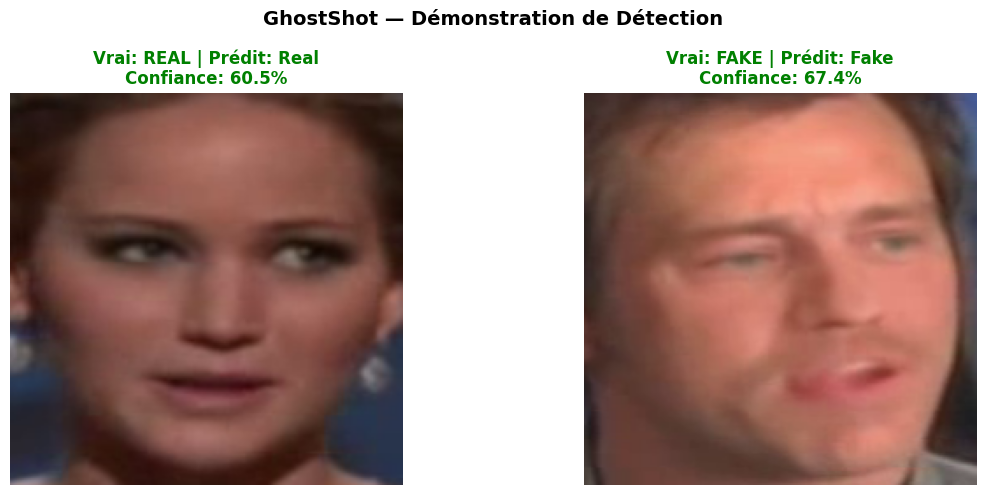

✅ Sauvegardé!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image réelle correctement classée
real_path = random.choice(real_imgs)
pred, probs = predict(real_path)
img = cv2.cvtColor(cv2.imread(str(real_path)), cv2.COLOR_BGR2RGB)
axes[0].imshow(cv2.resize(img, (224, 224)))
axes[0].set_title(f"Vrai: REAL | Prédit: {'Real' if pred==0 else 'Fake'}\n"
                  f"Confiance: {probs[pred]*100:.1f}%",
                  color="green" if pred==0 else "red", fontweight="bold")
axes[0].axis("off")

# Image fake correctement classée
fake_path = random.choice(fake_imgs)
pred, probs = predict(fake_path)
img = cv2.cvtColor(cv2.imread(str(fake_path)), cv2.COLOR_BGR2RGB)
axes[1].imshow(cv2.resize(img, (224, 224)))
axes[1].set_title(f"Vrai: FAKE | Prédit: {'Real' if pred==0 else 'Fake'}\n"
                  f"Confiance: {probs[pred]*100:.1f}%",
                  color="green" if pred==1 else "red", fontweight="bold")
axes[1].axis("off")

plt.suptitle("GhostShot — Démonstration de Détection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/demo_final.png", dpi=150)
plt.show()
print("✅ Sauvegardé!")

🔍 Testing on REAL face...


/tmp/ipykernel_2635/2739185657.py:70: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2635/2739185657.py:71: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("results/figures/demo_prediction.png", dpi=150, facecolor="#1a1a2e")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


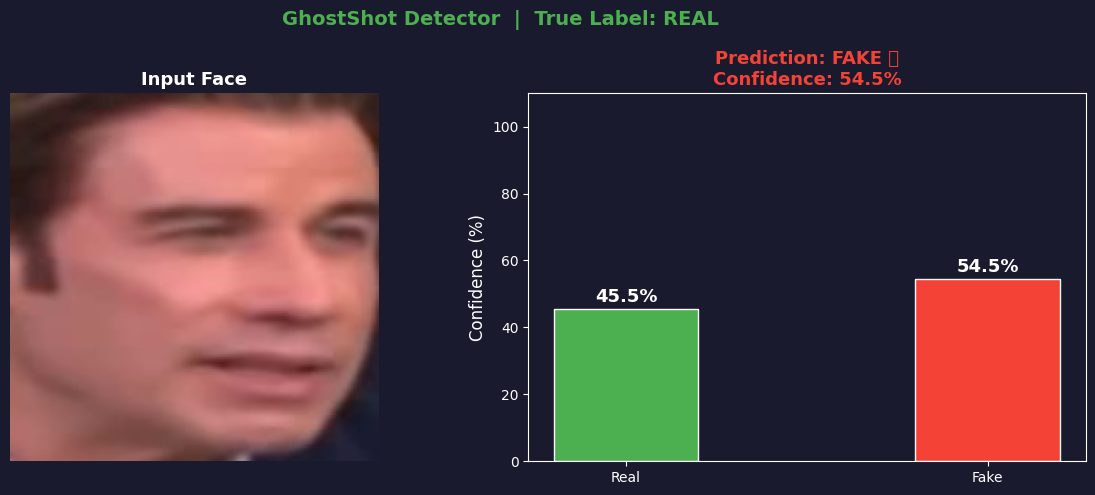


  GhostShot Prediction
  True label : REAL
  Prediction : FAKE ❌
  Real prob  : 45.5%
  Fake prob  : 54.5%


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
import random

random.seed(42)

transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def predict_and_show(img_path, true_label):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(probs.argmax())

    label_names = {0: "REAL", 1: "FAKE"}
    confidence  = probs[pred] * 100
    correct     = pred == true_label

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor("#1a1a2e")

    axes[0].imshow(img_resized)
    axes[0].set_title("Input Face", fontsize=13, color="white", fontweight="bold")
    axes[0].axis("off")

    colors = ["#4CAF50", "#f44336"]
    bars = axes[1].bar(["Real", "Fake"], probs * 100,
                       color=colors, width=0.4, edgecolor="white")
    axes[1].set_ylim(0, 110)
    axes[1].set_ylabel("Confidence (%)", color="white", fontsize=12)
    axes[1].set_facecolor("#1a1a2e")
    axes[1].tick_params(colors="white")
    for spine in axes[1].spines.values():
        spine.set_edgecolor("white")

    for bar, val in zip(bars, probs * 100):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 2,
                    f"{val:.1f}%", ha="center",
                    fontsize=13, fontweight="bold", color="white")

    result_color = "#4CAF50" if correct else "#f44336"
    result_icon  = "✅" if correct else "❌"
    axes[1].set_title(
        f"Prediction: {label_names[pred]} {result_icon}\nConfidence: {confidence:.1f}%",
        fontsize=13, color=result_color, fontweight="bold"
    )

    true_color = "#4CAF50" if true_label == 0 else "#f44336"
    fig.suptitle(
        f"GhostShot Detector  |  True Label: {label_names[true_label]}",
        fontsize=14, fontweight="bold", color=true_color
    )

    plt.tight_layout()
    plt.savefig("results/figures/demo_prediction.png", dpi=150, facecolor="#1a1a2e")
    plt.show()

    print(f"\n{'='*40}")
    print(f"  GhostShot Prediction")
    print(f"{'='*40}")
    print(f"  True label : {label_names[true_label]}")
    print(f"  Prediction : {label_names[pred]} {result_icon}")
    print(f"  Real prob  : {probs[0]*100:.1f}%")
    print(f"  Fake prob  : {probs[1]*100:.1f}%")
    print(f"{'='*40}")

# Demo on REAL face
print("🔍 Testing on REAL face...")
real_imgs = list(Path("data/processed/celebdf_real/0").rglob("*.png"))
predict_and_show(str(random.choice(real_imgs)), true_label=0)